## FFNN

In [61]:
import numpy as np
from ids_expt.data.dataset import (
    DataSetConfig,
    SamplingMethod,
    CLFDataSet as DataSet,
    DFDataSet,
)
from ids_expt.models.trainer import NNTrainer, NNTrainerConfig
from pathlib import Path
from loguru import logger
import pandas as pd
from sklearn.preprocessing import StandardScaler
from ids_expt.core.defs import TOP_CIC_FEATURES
from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import PyTorchClassifier
from pathlib import Path
import torch
from ids_expt.models.ffnn import FFNN
from torchmetrics import MetricCollection, Accuracy, Precision, Recall, F1Score, AUROC


model_path = Path(
    r"C:\Users\Viper\Desktop\thesis_code\results\cic_fnn\ctgan_oversampling\best_model.pth"
)


class ClfModel(torch.nn.Module):
    def __init__(self, model: torch.nn.Module):
        super(ClfModel, self).__init__()
        self.model = model

    def forward(self, x):

        return self.model(x)[0]


train_dataset, val_dataset = DFDataSet(
    config=DataSetConfig(
        csv_path=Path(r"E:\MSc Works\IDS\data\cicflow_combined.csv"),
        features=TOP_CIC_FEATURES,
        sampling_method=SamplingMethod.NONE,
        max_data=-1,
        train_ratio=0.8,
    )
).get_datasets()

model = FFNN(
    input_size=len(TOP_CIC_FEATURES),
    hidden_layers=[90] * 9,
    output_size=val_dataset.data.Label.nunique(),
    use_batchnorm=False,
)
model.load_state_dict(torch.load(model_path, map_location=torch.device("cpu")))
model = ClfModel(model)
model.eval()

train_df = pd.read_csv(r"E:\MSc Works\IDS\cic_merged_train_data.csv")
train_df.columns = train_df.columns.str.strip()
val_df = pd.read_csv(r"E:\MSc Works\IDS\cic_merged_test_data.csv")
val_df.columns = val_df.columns.str.strip()
X_train = train_df.drop(columns=["Label"])
y_train = train_df["Label"]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = val_df.drop(columns=["Label"])
y_val = val_df["Label"]
X_val = scaler.transform(X_val)
train_dataset.data = pd.DataFrame(X_train, columns=train_df.columns[:-1])
train_dataset.data["Label"] = y_train.values
val_dataset.data = pd.DataFrame(X_val, columns=val_df.columns[:-1])
val_dataset.data["Label"] = y_val.values

f1_score = F1Score(task="multiclass", num_classes=val_dataset.data.Label.nunique())

x_test = X_val.astype(np.float32).reshape(
    len(X_val), 1, len(TOP_CIC_FEATURES)
)  # Reshape for PyTorch input
y_test = np.array([val_dataset.label_encoding[label] for label in y_val]).astype(
    np.float32
)

c:\Users\Viper\Desktop\thesis_code\venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:628: UserWarning: <built-in function callable> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
2025-06-30 14:07:29.079 | INFO     | ids_expt.data.dataset:get_datasets:92 - Label counts in the dataset: {'NORMAL': 14705, 'DISABLE_UNSOLICITED': 5760, 'COLD_RESTART': 5760, 'WARM_RESTART': 5760, 'DNP3_ENUMERATE': 3368, 'DNP3_INFO': 3340, 'ARP_POISONING': 835, 'INIT_DATA': 720, 'STOP_APP': 720, 'REPLAY': 666, 'MITM_DOS': 130}
2025-06-30 14:07:29.129 | INFO     | ids_expt.data.dataset:get_datasets:108 - Training dataset sampled with label counts: {'NORMAL': 11764, 'DISABLE_UNSOLICITED': 4608, 'COLD_RESTART': 4608, 'WARM_RESTART': 4608, 'DNP3_ENUMERATE': 2694, 'DNP3_INFO': 2672, 'ARP_

## Model's F1

In [62]:
logits = model(torch.tensor(x_test)).squeeze(1)
probs = torch.softmax(logits, dim=1)
labels = torch.tensor(y_test, dtype=torch.float32)
orig_predictions = torch.argmax(probs, dim=1)
f1_score(orig_predictions, labels.argmax(dim=1))

tensor(0.9357)

## Adversarial F1

In [66]:
x_min, x_max = X_train.min(axis=0), X_train.max(axis=0)
clip_values = (x_min, x_max)
classifier = PyTorchClassifier(
    model=model,
    clip_values=clip_values,
    loss=torch.nn.CrossEntropyLoss(),  # Specify the loss function if needed
    input_shape=len(TOP_CIC_FEATURES),  # Adjust based on your input shape
    nb_classes=val_dataset.data.Label.nunique(),
    optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
)
# Step 6: Generate adversarial test examples
attack = FastGradientMethod(estimator=classifier, eps=1)
x_test_adv = attack.generate(x=x_test)

# Step 7: Evaluate the ART classifier on adversarial test examples
adv_predictions = classifier.predict(x_test_adv)

In [67]:
prediction = torch.nn.functional.softmax(
    torch.from_numpy(adv_predictions.reshape(-1, val_dataset.data.Label.nunique()))
)
f1_score(prediction.argmax(dim=1), labels.argmax(dim=1))

C:\Users\Viper\AppData\Local\Temp\ipykernel_12816\2354818302.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prediction = torch.nn.functional.softmax(


tensor(0.8906)

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])

Mean Absolute Deviation: 0.000015


TypeError: only length-1 arrays can be converted to Python scalars

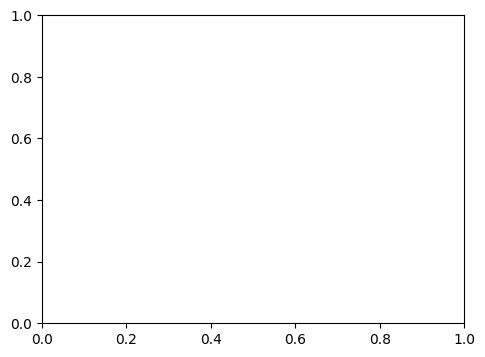

In [ ]:
import matplotlib.pyplot as plt

# Calculate mean absolute deviation
mad = np.abs(x_test_adv - x_test).mean()
print(f"Mean Absolute Deviation: {mad:.6f}")

# Visualize sample differences
sample_idx = 0
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.bar(range(len(TOP_CIC_FEATURES)), x_test[sample_idx])
plt.title("Original Features")
plt.subplot(122)
plt.bar(range(len(TOP_CIC_FEATURES)), x_test_adv[sample_idx] - x_test[sample_idx])
plt.title("Adversarial Perturbation")
plt.show()

## Image Clf

In [16]:
from ids_expt.models.cnn import CNN2D as SimpleCNN, BiggerCNN2D
from ids_expt.data.session_image_dataset import (
    SessionImageDataConfig,
    DFDataSet,
    TorchImageDataset,
    SamplingMethod,
)
from pathlib import Path
from loguru import logger
import torch
from torchmetrics import MetricCollection, Accuracy, Precision, Recall, F1Score, AUROC

config = SessionImageDataConfig(
    max_data=-100,
    session_images_dir=Path(
        r"C:\Users\Viper\Desktop\thesis_code\notebooks\120_timeout_dnp3_sessions\session_images"
    ),
    labels_file=Path(
        r"C:\Users\Viper\Desktop\thesis_code\notebooks\120_timeout_dnp3_sessions\labelled_sessions.csv"
    ),
    sampling_method=SamplingMethod.OVERSAMPLE,
)
train_ds, test_ds = DFDataSet(config=config).load_data()

model = BiggerCNN2D(
    in_channel=1,
    num_classes=len(train_ds.label_encoding),
    dropout_rate=0.1,
).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model.load_state_dict(
    torch.load(
        Path(
            r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\bigger_cnn2d\best_model.pth"
        ),
        map_location=torch.device("cuda"),
    )
)

2025-06-30 11:09:52.025 | INFO     | ids_expt.data.session_image_dataset:load_data:119 - Data loaded into DataFrame with 32960 entries
2025-06-30 11:09:52.028 | INFO     | ids_expt.data.session_image_dataset:load_data:120 - Label distribution:
label
NORMAL                 13761
COLD_RESTART            5760
WARM_RESTART            5760
DISABLE_UNSOLICITED     5760
INIT_DATA                692
STOP_APP                 680
REPLAY                   547
Name: count, dtype: int64
2025-06-30 11:09:52.029 | INFO     | ids_expt.data.session_image_dataset:load_data:125 - Final dataset size: 32960 entries after applying max_data limit
2025-06-30 11:09:52.072 | INFO     | ids_expt.data.session_image_dataset:load_data:154 - Oversampling to 10321 samples per class for training
2025-06-30 11:09:52.188 | INFO     | ids_expt.data.session_image_dataset:load_data:176 - Split data into 72247 training and 8240 testing samples
2025-06-30 11:09:52.189 | INFO     | ids_expt.data.session_image_dataset:load_dat

<All keys matched successfully>

In [53]:
from tqdm import tqdm

testds = TorchImageDataset(test_ds)
test_loader = torch.utils.data.DataLoader(
    testds,
    batch_size=32,
    shuffle=False,
)
f1_score = F1Score(task="multiclass", num_classes=len(test_ds.label_encoding))

predictions = []
targets = []

for images, labels in tqdm(test_loader):
    images = images.to(torch.float32)
    logits, proba = model(images.to("cuda"))
    preds = torch.argmax(proba, dim=1)
    predictions.extend(preds.cpu().numpy())
    targets.extend(labels.argmax(dim=1).cpu().numpy())

100%|██████████| 258/258 [00:19<00:00, 12.98it/s]


In [ ]:
f1 = f1_score(torch.tensor(predictions), torch.tensor(targets))
print(f"F1 Score: {f1:.4f}")

In [60]:
from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import PyTorchClassifier


class ClfModel(torch.nn.Module):
    def __init__(self, model: torch.nn.Module):
        super(ClfModel, self).__init__()
        self.model = model

    def forward(self, x):

        return self.model(x)[0]


test_loader = torch.utils.data.DataLoader(
    testds,
    batch_size=64,
    shuffle=False,
)
x_min, x_max = (0, 1)
clip_values = (x_min, x_max)
classifier = PyTorchClassifier(
    model=ClfModel(model),
    clip_values=clip_values,
    loss=torch.nn.CrossEntropyLoss(),
    input_shape=(1, 6 * 32, 8 * 32),
    nb_classes=test_ds.data_df.label.nunique(),
    optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
)

attack = FastGradientMethod(estimator=classifier, eps=0.01)
adv_predictions = []
targets = []
for images, labels in tqdm(test_loader):
    adv_images = attack.generate(x=images.numpy())
    adv_preds = classifier.predict(adv_images)
    adv_preds = torch.nn.functional.softmax(
        torch.from_numpy(adv_preds.reshape(-1, test_ds.data_df.label.nunique()))
    )
    adv_predictions.extend(adv_preds.argmax(axis=1))
    targets.extend(labels.argmax(dim=1).numpy())
f1_score = F1Score(task="multiclass", num_classes=test_ds.data_df.label.nunique())
f1 = f1_score(torch.tensor(adv_predictions), torch.tensor(targets))
print(f"F1 Score on Adversarial Examples: {f1:.4f}")

  0%|          | 0/129 [00:00<?, ?it/s]C:\Users\Viper\AppData\Local\Temp\ipykernel_14388\3423322273.py:37: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  adv_preds = torch.nn.functional.softmax(
100%|██████████| 129/129 [01:52<00:00,  1.14it/s]

F1 Score on Adversarial Examples: 0.2387


In [55]:
preds = torch.nn.functional.softmax(
    torch.from_numpy(adv_predictions.reshape(-1, test_ds.data_df.label.nunique()))
)
f1_score = F1Score(task="multiclass", num_classes=len(test_ds.label_encoding))
score = f1_score(preds.argmax(dim=1), torch.tensor(labels.argmax(dim=1)))
print(f"F1 Score on Adversarial Examples: {score:.4f}")

F1 Score on Adversarial Examples: 0.2500


C:\Users\Viper\AppData\Local\Temp\ipykernel_14388\851724519.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  preds = torch.nn.functional.softmax(
C:\Users\Viper\AppData\Local\Temp\ipykernel_14388\851724519.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  score = f1_score(preds.argmax(dim=1), torch.tensor(labels.argmax(dim=1)))


In [52]:
torch.tensor(targets).shape

torch.Size([8240])

## Adversarial Testing

In [78]:
from art.attacks.evasion.projected_gradient_descent.projected_gradient_descent import (
    ProjectedGradientDescent,
)
from loguru import logger
from art.estimators.classification import PyTorchClassifier
from ids_expt.utils.confusion_matrix import get_confusion_matrix
from torchmetrics import F1Score
from pathlib import Path
from ids_expt.data.session_image_dataset import (
    SessionImageDataConfig,
    DFDataSet,
    TorchImageDataset,
    SamplingMethod,
)
import cv2
import numpy as np


class ClfModel(torch.nn.Module):
    def __init__(self, model: torch.nn.Module):
        super(ClfModel, self).__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)[0]


class AdversarialExperiment:

    def __init__(
        self,
        model: torch.nn.Module,
        model_name: str,
        attacks: list[ProjectedGradientDescent],
        train_dataset: TorchImageDataset,
        test_dataset: TorchImageDataset,
        input_shape=(1, 6 * 32, 8 * 32),
        loss=torch.nn.CrossEntropyLoss(),
        clip_values=(0, 1),
        optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
        output_dir: Path = Path(
            r"C:\Users\Viper\Desktop\thesis_code\results\adversarial_experiment"
        ),
        device: str = "cuda" if torch.cuda.is_available() else "cpu",
    ):
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.model = model
        self.attacks = attacks
        self.input_shape = input_shape
        self.classifier = PyTorchClassifier(
            model=model,
            loss=loss,
            clip_values=clip_values,
            input_shape=input_shape,
            nb_classes=train_dataset.data.label.nunique(),
            optimizer=optimizer,
        )
        self.f1_score = F1Score(
            task="multiclass", num_classes=train_dataset.data.label.nunique()
        )
        self.output_dir = output_dir / model_name
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def run(self):
        for attack in self.attacks:
            logger.info(f"Running attack: {attack.__class__.__name__}")
            adv_predictions = []
            targets = []
            for images, labels in tqdm(
                torch.utils.data.DataLoader(
                    self.test_dataset, batch_size=64, shuffle=False
                )
            ):
                images = images.to(torch.float32)
                adv_images = attack.generate(x=images.numpy())
                adv_logits, adv_proba = self.model(torch.tensor(adv_images).to("cuda"))
                adv_preds = torch.argmax(adv_proba, dim=1)
                adv_predictions.extend(adv_preds.cpu().numpy())
                targets.extend(labels.argmax(dim=1).cpu().numpy())
            f1 = self.f1_score(torch.tensor(adv_predictions), torch.tensor(targets))
            logger.info(f"F1 Score on Adversarial Examples: {f1:.4f}")
            cm = get_confusion_matrix(
                adv_predictions,
                targets,
                self.train_dataset.label_encoding,
                out_file=self.output_dir / f"{attack.__class__.__name__}.png",
            )
            logger.info(f"Confusion Matrix:\n{cm}")
        
    def _generate(self, attack, out_folder, dataset,preserve_blank_areas=False):
        num_samples = len(dataset)
        if not (self.output_dir / out_folder).exists():
            (self.output_dir / out_folder).mkdir(parents=True, exist_ok=True)
        logger.info(f"Generating adversarial examples for {num_samples} samples")
        for sample_idx in tqdm(range(num_samples), desc="Generating adversarial examples"):
            row = dataset.dataset.data_df.iloc[sample_idx]
            # arr, arr, str
            image, label, label_str = dataset.dataset[sample_idx]
            adv_img = attack.generate(
                x=image.reshape(1, *self.input_shape).astype(np.float32)
            )
            adv_img = adv_img.reshape(self.input_shape[1:])
            # reverse normalize
            adv_img = adv_img * 255
            adv_img = adv_img.astype(np.uint8)
            # write to file
            filename = Path(row["file_path"]).name
            adv_img_path = self.output_dir / out_folder / filename
            if preserve_blank_areas:
                row_mask = np.all(image == 0, axis=1)
                col_mask = np.all(image == 0, axis=0)

                # Apply masks to adversarial image
                adv_img[row_mask, :] = 0
                adv_img[:, col_mask] = 0
            cv2.imwrite(str(adv_img_path), adv_img)

        logger.info('Done')

    def generate(
        self,
        attack: ProjectedGradientDescent,
        out_folder: str = "",
        preserve_blank_areas=False,
    ):
        logger.info(f"Generating adversarial examples for attack: {attack.__class__.__name__}")
        self._generate(
            attack, out_folder, self.train_dataset, preserve_blank_areas
        )
        logger.info(
            f"Train Adversarial examples saved to {self.output_dir / out_folder}"
        )
        self._generate(
            attack, out_folder, self.test_dataset, preserve_blank_areas
        )
        logger.info('Validation adversarial examples saved.')

In [120]:
model_path = Path(
    r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\bigger_cnn2d\best_model.pth"
)
config = SessionImageDataConfig(
    max_data=-100,
    session_images_dir=Path(
        r"C:\Users\Viper\Desktop\thesis_code\notebooks\120_timeout_dnp3_sessions\session_images"
    ),
    labels_file=Path(
        r"C:\Users\Viper\Desktop\thesis_code\notebooks\120_timeout_dnp3_sessions\labelled_sessions.csv"
    ),
    sampling_method=SamplingMethod.OVERSAMPLE,
)
train_ds, test_ds = DFDataSet(config=config).load_data()


model = BiggerCNN2D(
    in_channel=1,
    num_classes=len(train_ds.label_encoding),
    dropout_rate=0.1,
).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model.load_state_dict(
    torch.load(
        model_path,
        map_location=torch.device("cuda"),
    )
)

adv = AdversarialExperiment(
    model=model,
    model_name="bigger_cnn2d",
    attacks=[
        FastGradientMethod(
            estimator=PyTorchClassifier(
                model=ClfModel(model),
                loss=torch.nn.CrossEntropyLoss(),
                clip_values=(0, 1),
                input_shape=(1, 6 * 32, 8 * 32),
                nb_classes=len(train_ds.label_encoding),
                optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
            ),
            eps=0.1,
        )
    ],
    train_dataset=TorchImageDataset(train_ds),
    test_dataset=TorchImageDataset(test_ds),
)

2025-06-30 17:41:38.973 | INFO     | ids_expt.data.session_image_dataset:load_data:119 - Data loaded into DataFrame with 32960 entries
2025-06-30 17:41:38.976 | INFO     | ids_expt.data.session_image_dataset:load_data:120 - Label distribution:
label
NORMAL                 13761
COLD_RESTART            5760
WARM_RESTART            5760
DISABLE_UNSOLICITED     5760
INIT_DATA                692
STOP_APP                 680
REPLAY                   547
Name: count, dtype: int64
2025-06-30 17:41:38.977 | INFO     | ids_expt.data.session_image_dataset:load_data:125 - Final dataset size: 32960 entries after applying max_data limit
2025-06-30 17:41:39.019 | INFO     | ids_expt.data.session_image_dataset:load_data:154 - Oversampling to 10321 samples per class for training
2025-06-30 17:41:39.157 | INFO     | ids_expt.data.session_image_dataset:load_data:176 - Split data into 72247 training and 8240 testing samples
2025-06-30 17:41:39.158 | INFO     | ids_expt.data.session_image_dataset:load_dat

In [121]:
adv.run()

2025-06-30 17:41:39.237 | INFO     | __main__:run:67 - Running attack: FastGradientMethod
  5%|▍         | 6/129 [00:11<04:02,  1.97s/it]


KeyboardInterrupt: 

In [126]:
def generate(
    self,
    attack: ProjectedGradientDescent,
    out_folder: str = "",
    preserve_blank_areas=False,
):
    idx = 0
    num_samples = len(self.train_dataset)
    if not (self.output_dir / out_folder).exists():
        (self.output_dir / out_folder).mkdir(parents=True, exist_ok=True)
    logger.info(f"Generating adversarial examples for {num_samples} samples")

    for sample_idx in range(num_samples):
        row = self.train_dataset.dataset.data_df.iloc[sample_idx]
        # arr, arr, str
        image, label, label_str = self.train_dataset.dataset[sample_idx]
        adv_img = attack.generate(
            x=image.reshape(1, *self.input_shape).astype(np.float32)
        )
        adv_img = adv_img.reshape(self.input_shape[1:])
        # reverse normalize
        adv_img = adv_img * 255
        adv_img = adv_img.astype(np.uint8)
        # write to file
        filename = Path(row["file_path"]).name
        adv_img_path = self.output_dir / out_folder / filename
        if preserve_blank_areas:
            row_mask = np.all(image == 0, axis=1)
            col_mask = np.all(image == 0, axis=0)

            # Apply masks to adversarial image
            adv_img[row_mask, :] = 0
            adv_img[:, col_mask] = 0

        cv2.imwrite(str(adv_img_path), adv_img)
        return adv_img, (image * 255).astype(np.uint8)
        # logger.info(f"Saved adversarial image to {adv_img_path}")
        break


adv_img, real = generate(
    adv,
    attack=FastGradientMethod(
        estimator=PyTorchClassifier(
            model=ClfModel(model),
            loss=torch.nn.CrossEntropyLoss(),
            clip_values=(0, 1),
            input_shape=(1, 6 * 32, 8 * 32),
            nb_classes=len(train_ds.label_encoding),
            optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
        ),
        eps=0.01,
    ),
    out_folder="fgsm",
    preserve_blank_areas=True,
)

2025-06-30 17:42:08.309 | INFO     | __main__:generate:11 - Generating adversarial examples for 72247 samples


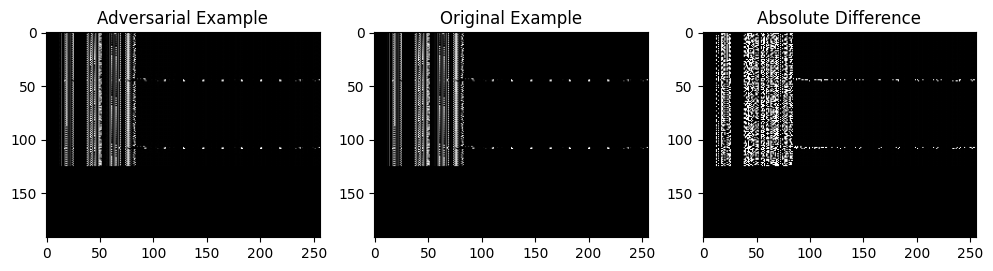

In [ ]:
# plot adv real and abs diff side by side
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(adv_img, cmap="gray")
plt.title("Adversarial Example")
plt.subplot(132)
plt.imshow(real, cmap="gray")
plt.title("Original Example")
plt.subplot(133)
plt.imshow(np.abs(adv_img - real).astype(np.uint8), cmap="gray", vmin=0, vmax=255)
plt.title("Absolute Difference")
plt.savefig(adv.output_dir / "fgsm" / "adversarial_example_comparison.png")
plt.show()

(255, 255, 255)